#### Dataset

##### Cài thư viện

In [2]:
!pip install idx2numpy

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for idx2numpy: filename=idx2numpy-1.2.3-py3-none-any.whl size=8022 sha256=e27857b3134f071664709a47647eb1b8dcaab512963f27f5f1f75173c794ff4e
  Stored in directory: c:\users\lenovo\appdata\local\pip\cache\wheels\f7\48\00\ae031c97d62f39e1c3c4daa00426c09a65eb29ae5753a189ee
Successfully built idx2numpy



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import idx2numpy
import pickle

image_file = "data/EMNIST/raw/emnist-balanced-train-images-idx3-ubyte"
label_file = "data/EMNIST/raw/emnist-balanced-train-labels-idx1-ubyte"

X = idx2numpy.convert_from_file(image_file)
y = idx2numpy.convert_from_file(label_file)

print(X.shape)
print(y.shape)

(112800, 28, 28)
(112800,)


In [4]:
data = {
    "x": X,
    "y": y
}

with open("data/emnist_full.pkl", "wb") as f:
    pickle.dump(data, f)

##### Chia iid

In [ ]:
import numpy as np
import os
import pickle

NUM_CLIENTS = 6

os.makedirs("data_new/iid", exist_ok=True)

num_samples = len(X)

indices = np.arange(num_samples)
np.random.shuffle(indices)

splits = np.array_split(indices, NUM_CLIENTS)

for i, idx in enumerate(splits):

    client_images = X[idx]
    client_labels = y[idx]

    with open(f"data_new/iid/client_{i}.pkl","wb") as f:
        pickle.dump({
            "images": client_images,
            "labels": client_labels
        }, f)

    print(f"client_{i}: {len(set(client_labels))} labels")

##### Chia Non_iid

In [11]:
import random
from collections import defaultdict
import os
import pickle

os.makedirs("data_new/non_iid", exist_ok=True)

NUM_CLIENTS = 6

label_dict = defaultdict(list)

for img, label in zip(X, y):
    label_dict[label].append(img)

labels = list(range(47))

for client in range(NUM_CLIENTS):

    missing = random.randint(5,10)

    remove_labels = set(random.sample(labels, missing))

    keep_labels = [l for l in labels if l not in remove_labels]

    client_images = []
    client_labels = []

    for l in keep_labels:

        imgs = label_dict[l]
        sample = random.sample(imgs, min(200, len(imgs)))

        client_images.extend(sample)
        client_labels.extend([l]*len(sample))

    with open(f"data_new/non_iid/client_{client}.pkl","wb") as f:
        pickle.dump({
            "images": client_images,
            "labels": client_labels
        }, f)

    print(f"client_{client}: {len(keep_labels)} labels")

client_0: 40 labels
client_1: 38 labels
client_2: 41 labels
client_3: 40 labels
client_4: 40 labels
client_5: 42 labels


#### Test Dataset

##### Kiểm tra số lượng nhãn

In [12]:
import os
import pickle

def count_labels_per_client(folder_path):
    print(f"\n===== {folder_path} =====")

    for file in sorted(os.listdir(folder_path)):
        if file.endswith(".pkl"):
            with open(os.path.join(folder_path, file), "rb") as f:
                data = pickle.load(f)

            y = data["labels"]
            num_labels = len(set(y)) 

            print(f"{file}: {num_labels} labels")

count_labels_per_client("./data_new/iid")
count_labels_per_client("./data_new/non_iid")


===== ./data_new/iid =====
client_0.pkl: 47 labels
client_1.pkl: 47 labels
client_2.pkl: 47 labels
client_3.pkl: 47 labels
client_4.pkl: 47 labels
client_5.pkl: 47 labels

===== ./data_new/non_iid =====
client_0.pkl: 40 labels
client_1.pkl: 38 labels
client_2.pkl: 41 labels
client_3.pkl: 40 labels
client_4.pkl: 40 labels
client_5.pkl: 42 labels


##### Kiểm tra số lượng mẫu

In [13]:
import os
import pickle

def count_samples_per_client(folder_path):
    print(f"\n===== {folder_path} =====")

    for file in sorted(os.listdir(folder_path)):
        if file.endswith(".pkl"):
            with open(os.path.join(folder_path, file), "rb") as f:
                data = pickle.load(f)

            y = data["labels"]
            num_samples = len(y)

            print(f"{file}: {num_samples} samples")


# chạy
count_samples_per_client("./data_new/iid")
count_samples_per_client("./data_new/non_iid")


===== ./data_new/iid =====
client_0.pkl: 3134 samples
client_1.pkl: 3134 samples
client_2.pkl: 3133 samples
client_3.pkl: 3133 samples
client_4.pkl: 3133 samples
client_5.pkl: 3133 samples

===== ./data_new/non_iid =====
client_0.pkl: 8000 samples
client_1.pkl: 7600 samples
client_2.pkl: 8200 samples
client_3.pkl: 8000 samples
client_4.pkl: 8000 samples
client_5.pkl: 8400 samples


##### Hình chi tiết từng client

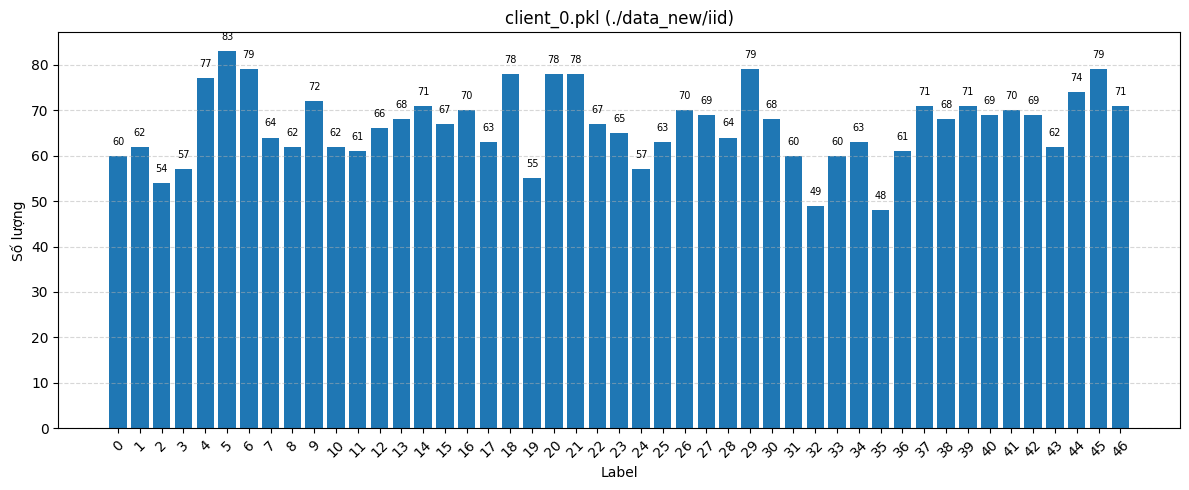

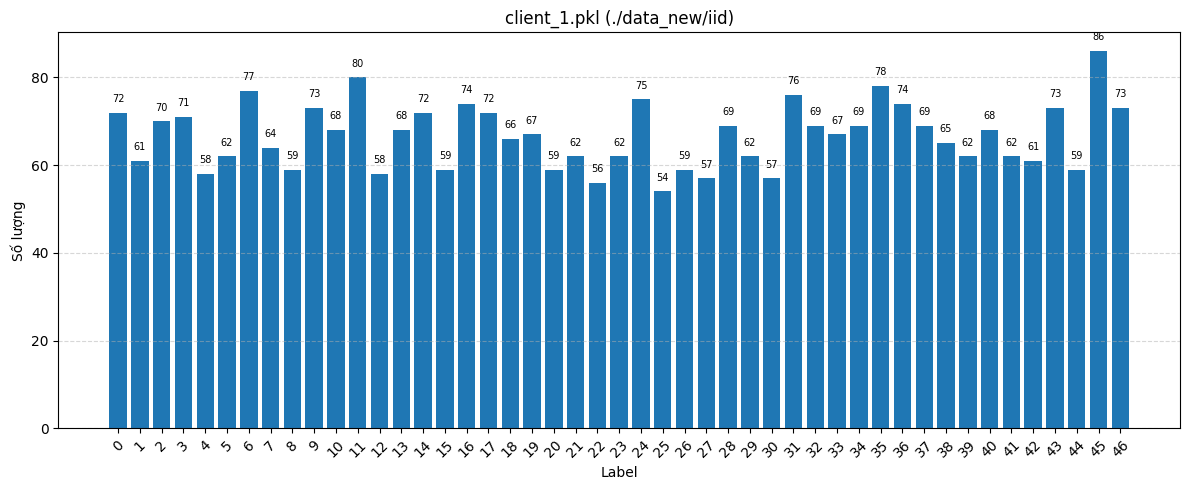

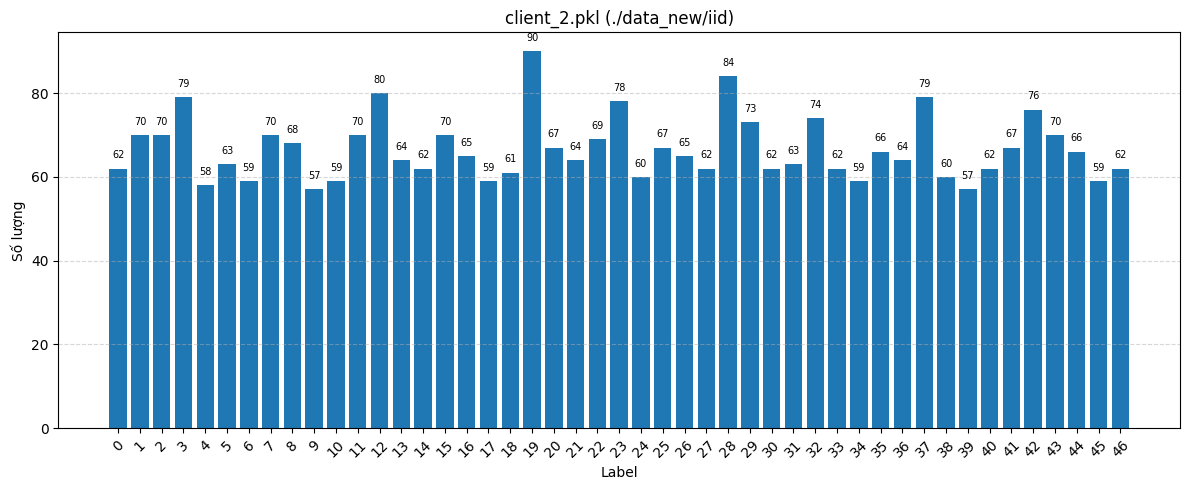

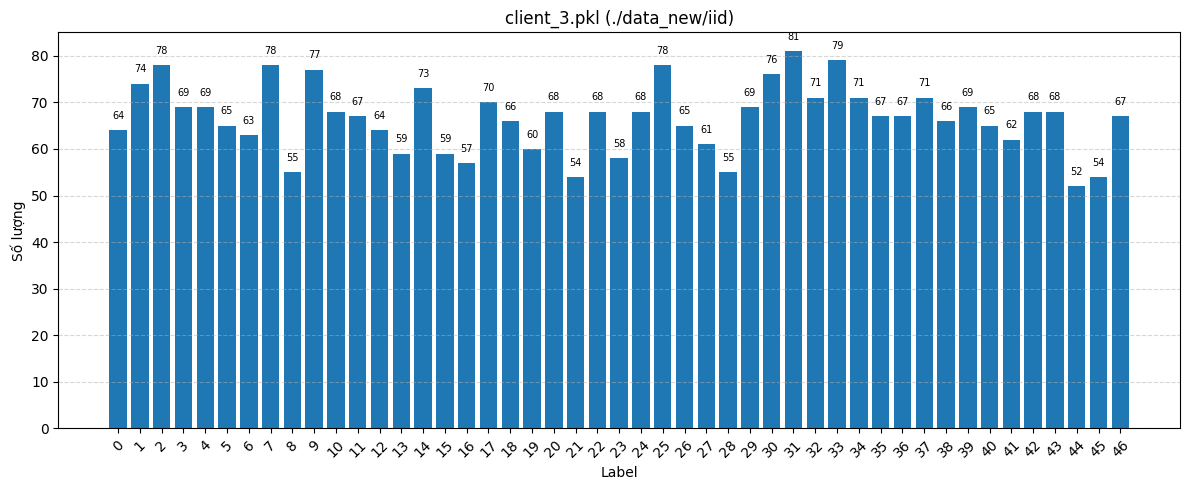

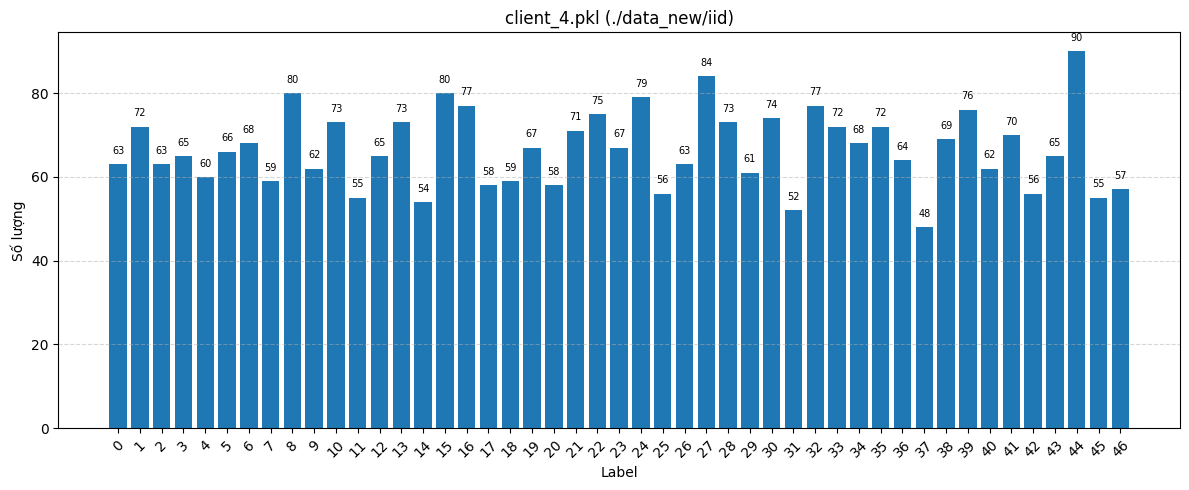

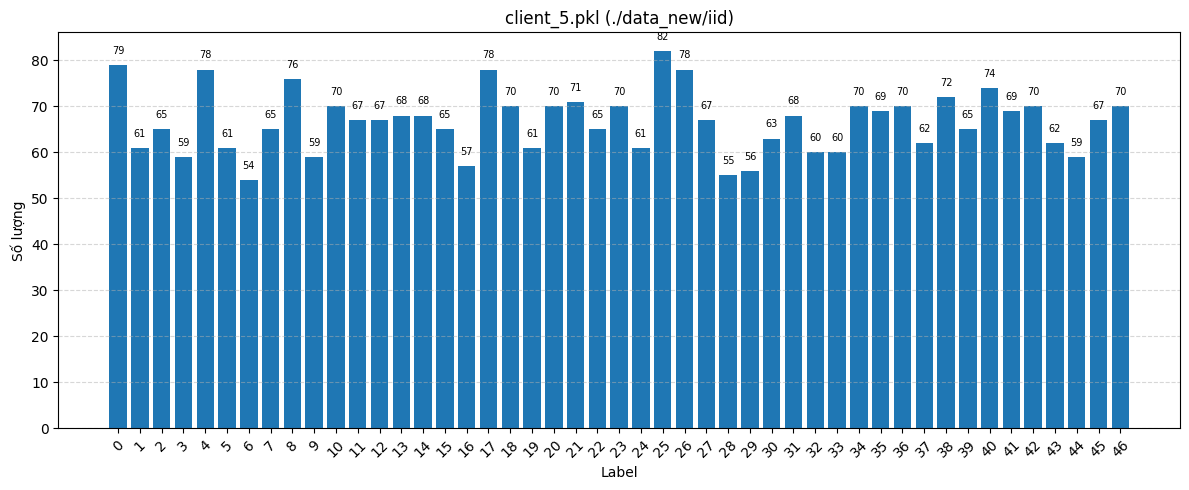

In [14]:
import os
import pickle
from collections import Counter
import matplotlib.pyplot as plt

def plot_each_client_beautiful(folder_path):
    files = sorted([f for f in os.listdir(folder_path) if f.endswith(".pkl")])

    for file in files:
        with open(os.path.join(folder_path, file), "rb") as f:
            data = pickle.load(f)

        y = data["labels"]
        counter = Counter(y)

        all_labels = list(range(max(counter.keys()) + 1))
        values = [counter.get(l, 0) for l in all_labels]

        plt.figure(figsize=(12,5))
        bars = plt.bar(all_labels, values)

        for bar in bars:
            height = bar.get_height()
            if height > 0:
                plt.text(bar.get_x() + bar.get_width()/2,
                         height + 2,
                         str(int(height)),
                         ha='center', va='bottom', fontsize=7)

        plt.xticks(all_labels, rotation=45) 

        plt.xlabel("Label")
        plt.ylabel("Số lượng")
        plt.title(f"{file} ({folder_path})")

        plt.grid(axis='y', linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.show()

plot_each_client_beautiful("./data_new/iid")

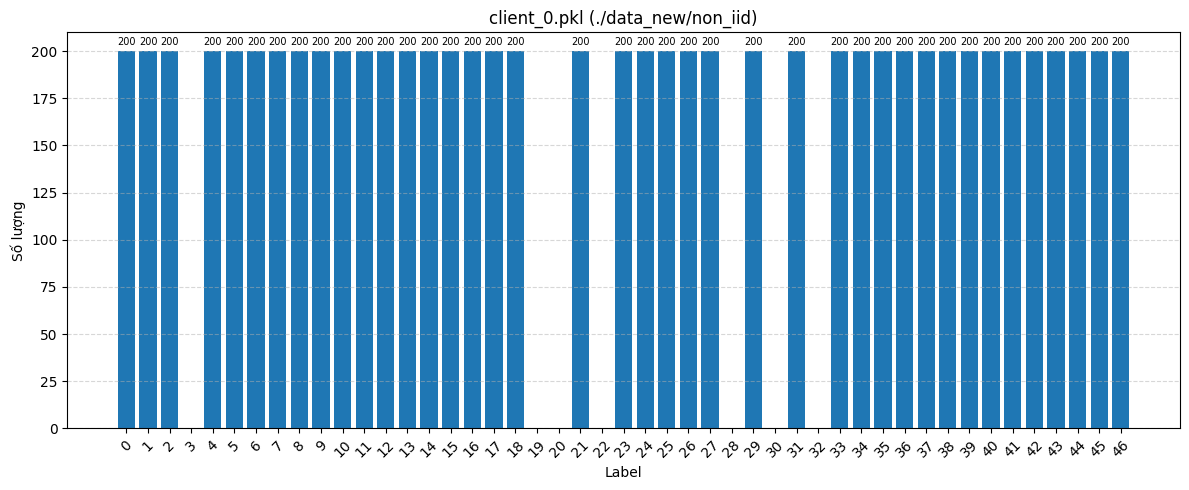

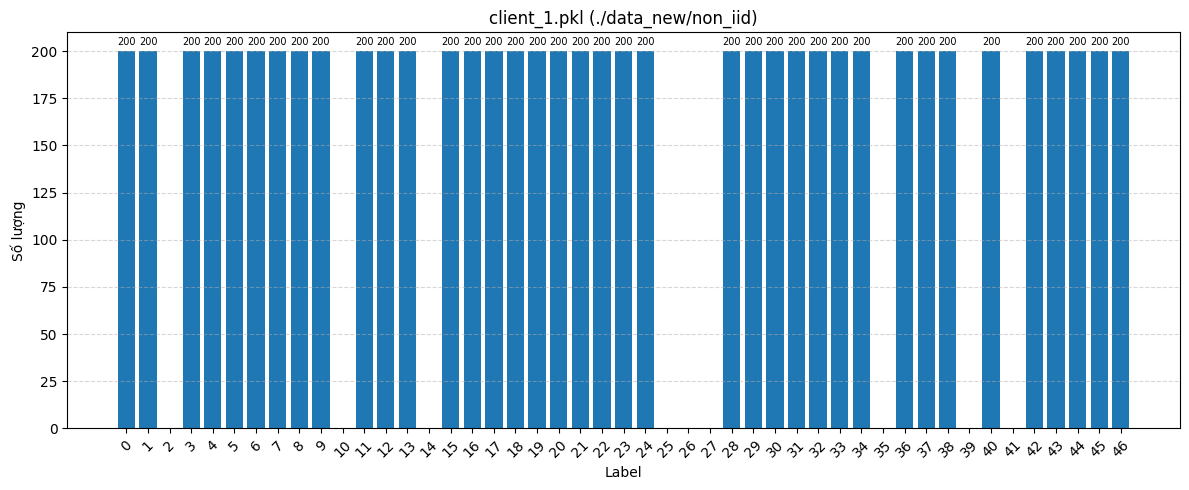

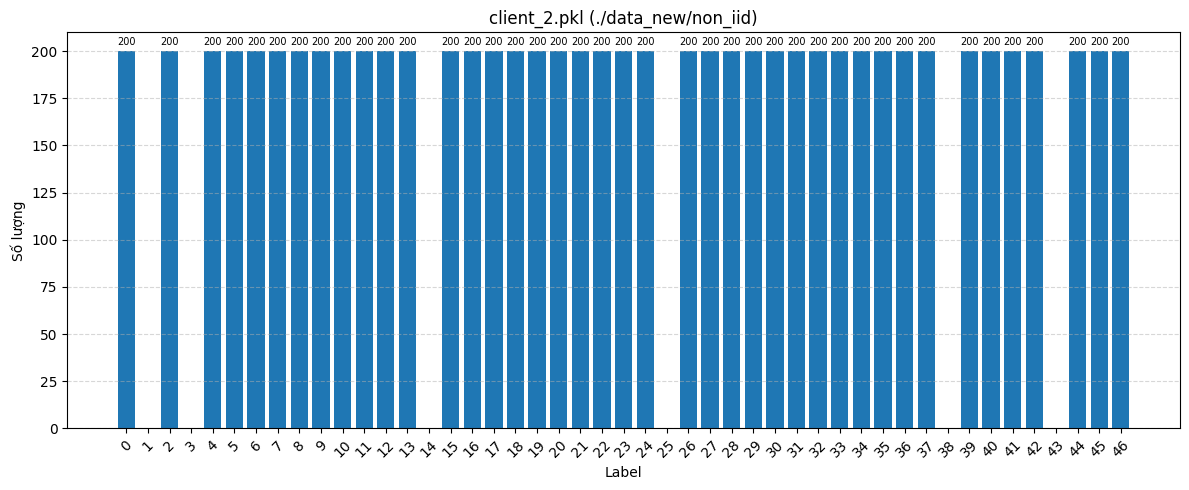

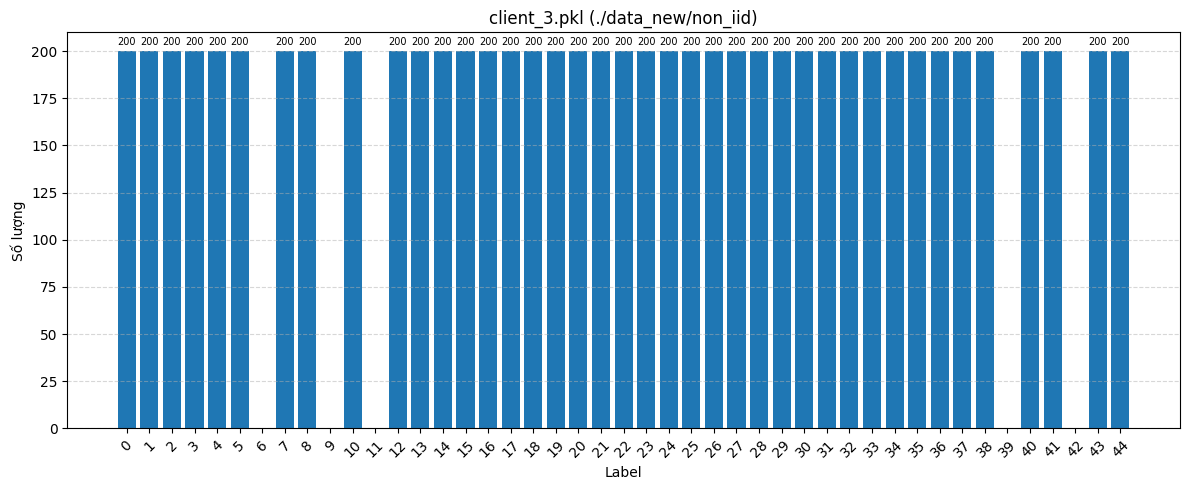

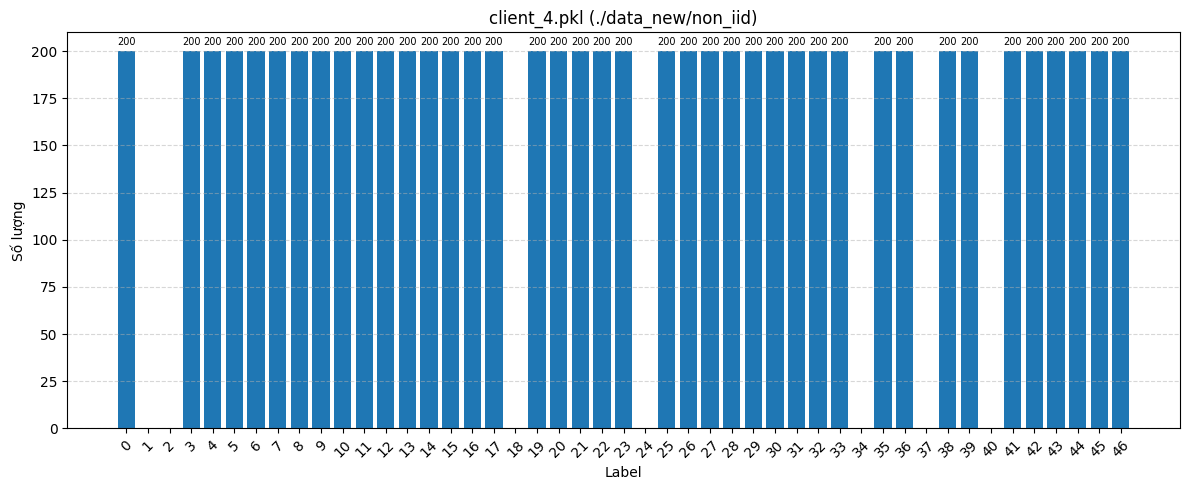

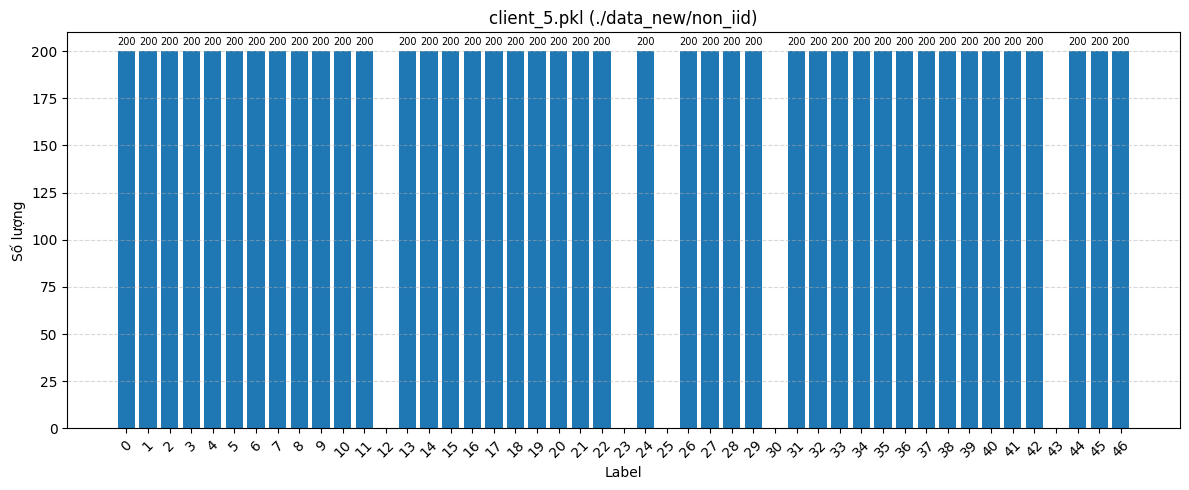

In [15]:
import os
import pickle
from collections import Counter
import matplotlib.pyplot as plt

def plot_each_client_beautiful(folder_path):
    files = sorted([f for f in os.listdir(folder_path) if f.endswith(".pkl")])

    for file in files:
        with open(os.path.join(folder_path, file), "rb") as f:
            data = pickle.load(f)

        y = data["labels"]
        counter = Counter(y)

        all_labels = list(range(max(counter.keys()) + 1))
        values = [counter.get(l, 0) for l in all_labels]

        plt.figure(figsize=(12,5))
        bars = plt.bar(all_labels, values)

        for bar in bars:
            height = bar.get_height()
            if height > 0:
                plt.text(bar.get_x() + bar.get_width()/2,
                         height + 2,
                         str(int(height)),
                         ha='center', va='bottom', fontsize=7)

        plt.xticks(all_labels, rotation=45) 

        plt.xlabel("Label")
        plt.ylabel("Số lượng")
        plt.title(f"{file} ({folder_path})")

        plt.grid(axis='y', linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.show()


# chạy
plot_each_client_beautiful("./data_new/non_iid")